# P1 · Generate one token at a time

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.17 · Generate one token at a time

Choose from the last position’s distribution, append the selected ID, then calculate the next prediction from the updated context.

**Prerequisites:** Evaluation and repeatable experiments

**Predict:** Which time position supplies the next-token distribution?

**Mental model:** The model predicts a distribution over the next token. Generation turns that one-step prediction into a sequence by repeating prediction and selection.

### Why this operation exists

The model predicts a distribution over the next token. Generation turns that one-step prediction into a sequence by repeating prediction and selection.

Only the last available time position supplies the next-token distribution. Earlier positions describe earlier next-token questions.

Greedy decoding selects a largest-score candidate. Sampling instead draws an ID according to the predicted probabilities, so different draws can produce different continuations.

Temperature rescales the logits before softmax. A positive higher temperature typically spreads probability more evenly; it does not add learned knowledge.

Append the selected ID, keep the permitted recent context, and run the model again. A recorded sample must identify how its selection was performed.

### Follow the values

Begin with one sequence containing IDs zero and one. The example supplies fixed illustrative logits to isolate selection from model computation.

The candidate scores are two, one and zero. These are three alternatives at the final time position, not scores for three time steps.

At temperature one, softmax gives the largest score the largest probability. Temperature two makes the distribution less concentrated.

Multinomial draws one ID using a seeded generator. The sampled tensor keeps a batch axis and a singleton selection axis.

Concatenate the selected ID along time. The full sequence grows, while a context crop can keep only the recent positions used for the next model call.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
ids = torch.tensor([[0,1]])
show("Current context", ids)
logits = torch.tensor([[2.,1.,0.]])
show("Illustrative last-position logits", logits)
temperature = 2. if change else 1.
probabilities = (logits/temperature).softmax(-1)
show("Candidate probabilities", probabilities)
next_id = torch.multinomial(probabilities, 1, generator=torch.Generator().manual_seed(7))
show("Sampled next ID [B,1]", next_id)
extended = torch.cat([ids,next_id], dim=1)
show("Append; then crop if needed", {"full sequence": extended.tolist(), "last two positions": extended[:, -2:].tolist()})

Current context: [[0, 1]]
  shape [1, 2] · torch.int64 · cpu
Illustrative last-position logits: [[2.0, 1.0, 0.0]]
  shape [1, 3] · torch.float32 · cpu
Candidate probabilities: [[0.6652409434318542, 0.2447284758090973, 0.09003057330846786]]
  shape [1, 3] · torch.float32 · cpu
Sampled next ID [B,1]: [[0]]
  shape [1, 1] · torch.int64 · cpu
Append; then crop if needed: {"full sequence": [[0, 1, 0]], "last two positions": [[1, 0]]}


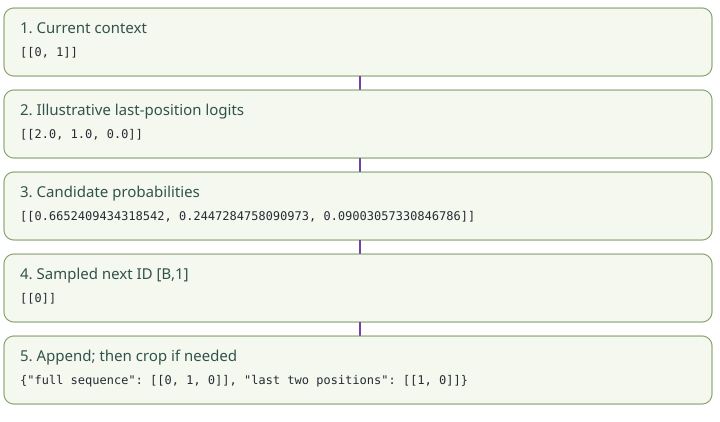

In [4]:
draw_trace()

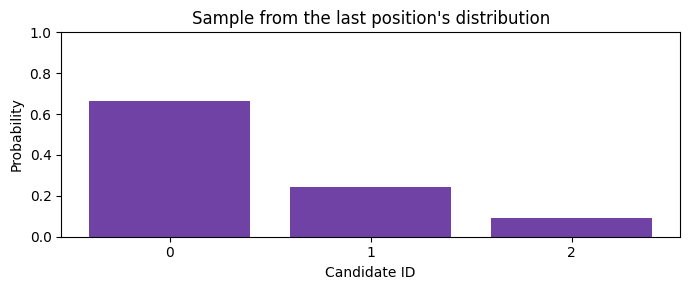

In [5]:
plt.figure(figsize=(7,3)); plt.bar(range(3),probabilities[0].numpy(),color="#7042a6")
plt.xticks(range(3)); plt.xlabel("Candidate ID"); plt.ylabel("Probability"); plt.ylim(0,1)
plt.title("Sample from the last position's distribution"); plt.tight_layout(); plt.show()

### Read the implementation

Select logits at the final time position before sampling. Divide by a strictly positive temperature, then normalize over the vocabulary axis.

Argmax implements a greedy selection. Multinomial takes nonnegative weights, here normalized probabilities, and returns integer candidate IDs.

Preserve shape batch by one for the sampled IDs so cat can extend the time axis of the input batch.

Top-k restricts candidates by replacing excluded logits before softmax. More advanced nucleus filtering is developed in the later decoding lesson.

Stop according to the generation contract: a requested length, an end-token policy, or both. Batched stopping requires tracking each example rather than treating many IDs as one scalar.

### Change one thing

**Raise temperature to 2**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
ids = torch.tensor([[0,1]])
show("Current context", ids)
logits = torch.tensor([[2.,1.,0.]])
show("Illustrative last-position logits", logits)
temperature = 2. if change else 1.
probabilities = (logits/temperature).softmax(-1)
show("Candidate probabilities", probabilities)
next_id = torch.multinomial(probabilities, 1, generator=torch.Generator().manual_seed(7))
show("Sampled next ID [B,1]", next_id)
extended = torch.cat([ids,next_id], dim=1)
show("Append; then crop if needed", {"full sequence": extended.tolist(), "last two positions": extended[:, -2:].tolist()})

Current context: [[0, 1]]
  shape [1, 2] · torch.int64 · cpu
Illustrative last-position logits: [[2.0, 1.0, 0.0]]
  shape [1, 3] · torch.float32 · cpu
Candidate probabilities: [[0.5064803957939148, 0.30719590187072754, 0.18632373213768005]]
  shape [1, 3] · torch.float32 · cpu
Sampled next ID [B,1]: [[0]]
  shape [1, 1] · torch.int64 · cpu
Append; then crop if needed: {"full sequence": [[0, 1, 0]], "last two positions": [[1, 0]]}


### A useful distinction

Temperature changes a distribution produced by the current weights. It does not train the model.

In [7]:
z = torch.tensor([[2.,1.,0.]])
threshold = torch.topk(z,2,dim=-1).values[:, -1:]
p = z.masked_fill(z < threshold, -float("inf")).softmax(-1)
assert p[0,2].item() == 0
assert torch.allclose(p.sum(-1), torch.ones(1))
print("Top-k threshold filtering:", p.tolist())

Top-k threshold filtering: [[0.7310585975646973, 0.2689414322376251, 0.0]]


### ✋ Your turn

Append ID 2 to the sequence [[0,1]] along its time axis and put the nested list in answer.

In [8]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[0,1,2]], 'Temperature changes a distribution produced by the current weights. It does not train the model.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [9]:
#@title Show a solution { display-mode: "form" }
answer = torch.cat([torch.tensor([[0,1]]), torch.tensor([[2]])], dim=1).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[0,1,2]], 'Temperature changes a distribution produced by the current weights. It does not train the model.'
    print("✓ right:", answer)

✓ right: [[0, 1, 2]]


### Reconnect to the transformer

The current generator repeatedly crops to its maximum context, calls the model, selects the final logits, samples and appends. Every iteration computes a new distribution.

Learned absolute position indices are recreated for the supplied window. Context cropping and position conventions should match the trained architecture.

Phyll also has an end-token convention and optional top-k filtering. Its tokenizer determines how selected IDs decode to text pieces.

One update of an untrained model does not establish coherent language. The training unit's recorded checkpoints show how generation changes over meaningful training progress.

Next, run the complete tiny model and preserve its learned state through a save-and-load round trip.

```python
logits, _ = self(idx[:, -self.cfg.block_size:])
probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
nxt = torch.multinomial(probs, 1, generator=generator)
idx = torch.cat([idx, nxt], dim=1)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which time position supplies the next-token distribution?

<details><summary>Check your explanation</summary>

The final available position. Temperature changes a distribution produced by the current weights. It does not train the model.

</details>